In [1]:
import pandas as pd
import numpy as np
import pickle
import time
import re
from newsdataapi import NewsDataApiClient
from newsapi import NewsApiClient
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.corpus import wordnet
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import train_test_split
from nltk.tokenize import TreebankWordTokenizer
from nltk.stem import WordNetLemmatizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('vader_lexicon')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\lovet\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\lovet\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\lovet\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

## Obtaining training data for the LDA

The URL data used as a starting point for training the LDA model originally came from repeated "latest news" calls via the NewsData.io API between the dates of 6th and 8th May 2026.
The below functions exist only for display purposes in this Notebook as they are no longer actively in use.

In [2]:
api = NewsDataApiClient(apikey="pub_7778e8573b82439795e6a1ae9b9fef79")

def get_API_results(startFrom, finishAt):
    i = startFrom
    while i < finishAt:
        # call the API
        response = api.latest_api(country='nz',language='en')
        # appending the loop count to the filename so it doesn't write over the same file repeatedly
        filename = "Pickles/newsdata_latest_nz_0" + str(i) + ".pkl" 
        # Pickling the response
        with open(filename, 'wb') as f:
            pickle.dump(response, f)
        # print out a message so we know how far along in the loop it is
        print(f"completed: {i}")
        # Increment i so the loop eventually stops (see while condition)
        i += 1  
        # 300 seconds = 5 minutes before starting the loop again
        time.sleep(300) 

def frameify_results(theseresults):
    training_df = pd.DataFrame(columns=['Date','Source','Title','Description','page_url'])
    results_list = []
    for i in theseresults:

        # 1. Handle Keywords
        keywords = i['keywords']
        keywords = ' '.join(keywords) if isinstance(keywords, list) else str(keywords or '')
        
        html_text = i['description'] or ''
        clean_text = re.sub(r'<.*?>', '', html_text)

        new_row = {
            'Date': i['pubDate'], 
            'Source': i['source_id'], 
            'Title':i['title'],
            'Description': clean_text.strip(),
            'Keywords' : keywords.strip(),
            'page_url':i['link']
            }
        results_list.append(new_row)
    new_df = pd.DataFrame(results_list)
    training_df = pd.concat([training_df,new_df],axis=0)
    return training_df

def readNewsPickles(thismany):
    newsPickleFiles = []
    numPickles = thismany
    newsPickles = []

    for i in range(9):
        # appending the loop count to the filename so it adds the current number to the string
        # they all follow the same naming convention - I renamed a few to make sure of it
        filename = "Pickles/newsdata_latest_nz_00" + str(i+1) + ".pkl" 
        newsPickleFiles.append(filename)

    for i in range(9,numPickles):
        # appending the loop count to the filename so it adds the current number to the string
        # they all follow the same naming convention - I renamed a few to make sure of it
        filename = "Pickles/newsdata_latest_nz_0" + str(i+1) + ".pkl" 
        newsPickleFiles.append(filename)

    for item in newsPickleFiles:
        with open(item, 'rb') as file:
            pickled = pickle.load(file)
            newsPickles.append(frameify_results(pickled['results']))
    
    return pd.concat(newsPickles,axis=0)    

The source URLs for each page obtained via this method were exported to a CSV, and then this was used to manually gather the body text of the news articles.
This was done due to the constraints of the NewsData.io API (it does not allow you to view the full articles it retrieves unless you are on a paid subscription).

This CSV can be found in the Datasets folder - 'Datasets/news_urls.csv'.

## Training the LDA for Topic Modelling

The below dataset comes from the news articles collected using the above mentioned method.

In [3]:
# Bringing in the original article set plus more collected
news_training_df = pd.read_excel('Datasets/FullNewsArticles190.xlsx')
news_content = news_training_df['Description']
news_content = news_content.str.replace('\n', ' ', regex=False) # get rid of newline characters

These next functions are for preprocessing the data.

In [4]:
lemmatizer = WordNetLemmatizer()
tokenizer = TreebankWordTokenizer()

def preprocess_text(text):
    text = re.sub('\'\n', '', text)  # Remove apostrophes and newlines
    text = re.sub('[^a-zA-Z]', ' ', text)  # Remove non-alphabet characters
    text = text.lower()  # Convert to lowercase
    return text

# This function is for identifying/tagging different parts of speech in the text
def get_wordnet_pos(treebank_tag):
    # Function to map Treebank POS tags to WordNet POS tags
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN # Default to noun

# This function is for lemmatization (which improves when the parts of speech are tagged accordingly, 
# otherwise it defaults to treating everything as a Noun)
def lemmatize_tokenizer(text):   
    tokens = tokenizer.tokenize(str(text))
    # 3. Apply POS Tagging & Lemmatization
    lemmatized = [lemmatizer.lemmatize(token, get_wordnet_pos(tag)) 
                  for token, tag in nltk.pos_tag(tokens)]
    return " ".join(lemmatized)

In [5]:
# Preprocessing and lemmatizing
news_training_df['Content'] = news_training_df['Description'].apply(preprocess_text)
news_training_df['Content'].astype(str).apply(lemmatize_tokenizer)

news_content = news_training_df['Content']

# Load the default English stop words
stop_words = stopwords.words('english')
stop_words = list(stop_words)

Split the data into testing and training

In [6]:
X_train, X_test = train_test_split(news_content, test_size=0.2, random_state=25)

print(f"Articles (training): {X_train.shape[0]}")
print(f"Articles (testing): {X_test.shape[0]}")

Articles (training): 152
Articles (testing): 38


In [7]:
# Initialise the LDA for 5 topics (n_components is the number of topics it generates)
lda = LatentDirichletAllocation(n_components=5, random_state=42) 
# Convert text to a Count Matrix for use with LDA (Vectorize while removing stop words)
vectorizer = CountVectorizer(stop_words=stop_words)
news_term_matrix = vectorizer.fit_transform(X_train)

# Fit and Transform the LDA model
lda_output = lda.fit_transform(news_term_matrix)
lda_topics = lda.transform(news_term_matrix)

# Quick check to make sure the parameters it's accepting/expecting are the same length
print("Vectorizer features:", news_term_matrix.shape[1])
print("LDA expected features:", lda.components_.shape[1])

Vectorizer features: 9456
LDA expected features: 9456


In [8]:
# Print top words for each topic
words = vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(lda.components_):
    print(f"\nTopic #{topic_idx}:")
    print([words[i] for i in topic.argsort()[:-6:-1]])


Topic #0:
['said', 'rugby', 'new', 'year', 'zealand']

Topic #1:
['said', 'people', 'new', 'also', 'percent']

Topic #2:
['said', 'new', 'river', 'rivers', 'us']

Topic #3:
['said', 'us', 'trump', 'iran', 'war']

Topic #4:
['said', 'new', 'would', 'year', 'also']


### Perplexity
Whether or not the model is doing well can be measured by its perplexity score for each topic.

Perplexity tells us whether or not the model is effectively being "surprised" by what words come next versus what its expecting for each topic. Low perplexity is good (this means there's not too many suprises), high perplexity is bad (it is being bamboozled).

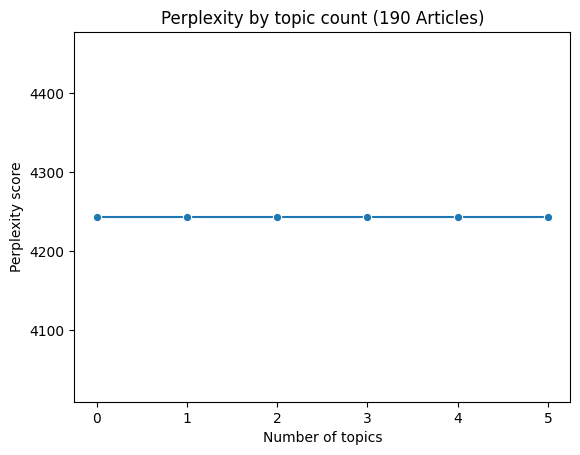

In [9]:
perplexity_score = []
topic_nums = range(6)

for topics in topic_nums:
    lda.fit(news_term_matrix)
    perplexity_score.append(lda.perplexity(news_term_matrix))  

# Plot perplexity by topic count
ax = sns.lineplot(x = topic_nums, y = perplexity_score, marker = 'o')
ax.set_title('Perplexity by topic count (190 Articles)')
ax.set_ylabel('Perplexity score'); ax.set_xlabel('Number of topics')
plt.show()

Good news / bad news
- Good news: the line is constant so the perplexity is consistent across all topics
- Bad news: The score is consistently very high across all topics. We kinda wanna bring that down, a bit.

In [10]:
# Save the model to a file
with open('Models/lda_model.pkl', 'wb') as file:
    pickle.dump(lda, file)

### Train, Test, Split: The Test
Let's actually have a go at testing the trained model, this time, by applying it to new data it hasn't seen yet.
- Trained Vectorizer: `vectorizer`
- Trained LDA: `lda`
- New data: `X_test`

In [11]:
# Use the trained vectorizer to transform new data
X_testing = vectorizer.transform(X_test) 

# Use the trained LDA model to get topic distributions
lda_topics_test = lda.transform(X_testing)

# Get the perplexity scores again
perplexity_score_testers = []
topic_nums = range(6)

for topics in topic_nums:
    lda.fit(lda_topics_test)
    perplexity_score_testers.append(lda.perplexity(lda_topics_test))  

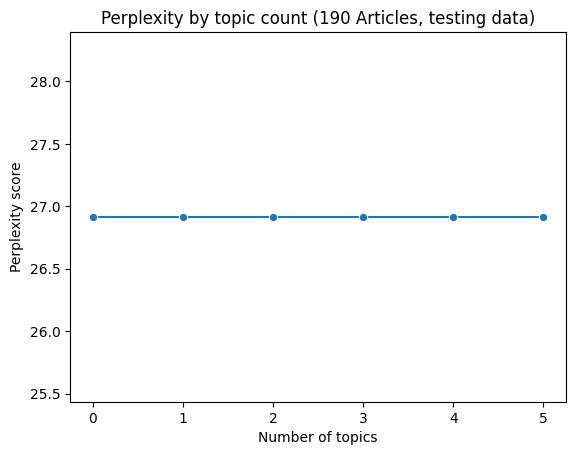

In [12]:
# Plot perplexity by topic count
ax = sns.lineplot(x = topic_nums, y = perplexity_score_testers, marker = 'o')
ax.set_title('Perplexity by topic count (190 Articles, testing data)')
ax.set_ylabel('Perplexity score'); ax.set_xlabel('Number of topics')
plt.show()

Generally speaking we would anticipate the perplexity score to be higher on the new data than it was on the training data, so this model still definitely needs a bit of tweaking, I think.

That's gonna have to wait for now, though - we need to move on.

# Getting more news

This next part is everything for getting more news, but using a different API that does let get the full article (but doesn't let us get news that specifically came from New Zealand news agents). It pulls the information it retrieves and then saves it to a pickle.

In [13]:
My_API_Key = '1637bcb3c78f458b82e58aaef00e4bbb'
newsapi = NewsApiClient(api_key=My_API_Key)

def get_NewsAPI_results(query, n):
    i = n
    response = newsapi.get_everything(q=query,language='en', from_param='2026-04-12', to='2026-05-12')
    # appending the n count to the filename so it doesn't write over the same file repeatedly
    filename = "Pickles/newsapi_geteverything" + str(i) + ".pkl" 
    # Pickling the response
    with open(filename, 'wb') as f:
        pickle.dump(response, f)

These next two are for reading in the pickles we've saved and then turning them into a dataframe.

In [14]:
def frameify_NewsAPI_pickles(theseresults):
    training_df = pd.DataFrame(columns=['Date','Source','Title','Description','page_url'])
    results_list = []
    for i in theseresults:
        
        html_text = i['description'] or ''
        clean_text = re.sub(r'<.*?>', '', html_text)

        # Fix the date time format (the API has it as something like 2020-04-20T22:11:00)
        api_date = i['publishedAt']
        formatted_date = api_date.split('T')[0]

        new_row = {
            'Date': formatted_date, 
            'Source': i['source']['name'], 
            'Title':i['title'],
            'Description': clean_text.strip(),
            'page_url':i['url']
            }
        results_list.append(new_row)
    new_df = pd.DataFrame(results_list)
    training_df = pd.concat([training_df,new_df],axis=0)
    return training_df

def readNewsAPIPickles(thismany):
    newsPickleFiles = []
    numPickles = thismany
    newsPickles = []

    for i in range(numPickles):
        # appending the loop count to the filename so it adds the current number to the string
        # they all follow the same naming convention - I renamed a few to make sure of it
        filename = "Pickles/newsapi_geteverything" + str(i+1) + ".pkl" 
        newsPickleFiles.append(filename)

    for item in newsPickleFiles:
        with open(item, 'rb') as file:
            pickled = pickle.load(file)
            newsPickles.append(frameify_NewsAPI_pickles(pickled['articles']))
    
    return pd.concat(newsPickles,axis=0)   

These are queries I've already made just to get at least some new articles on the books (metaphorically speaking):
- `get_API_results('climate change', 1)`
- `get_API_results('rugby', 2)`

<span style="color: #FF5F15">Important note:</span>
This is something we could potentially automate further down the track so that it can be scheduled as a... I wanna say 'once per day'? ie. set it up so that at 10:30am it makes a scheduled call for however/whatever queries we've set it up for and adds those to the existing dataframe.

# Applying the LDA to new data

Consider this next bit the absolute 'work in progress' of all work-in-progresses. This isn't what it'll look like when it's done, this is just setting up the bones of it so we know (at least some of) what we're doing after the LDA

In [15]:
bones_df = readNewsAPIPickles(2)
bones_df.reset_index(inplace=True)
bones_df.drop(columns='index',inplace=True)

# Preprocessing and lemmatizing
bones_df['Content'] = bones_df['Description'].apply(preprocess_text)
bones_df['Content'].astype(str).apply(lemmatize_tokenizer)

bones_content = bones_df['Content']

Load the trained model back in (avoiding annoying errors)

In [16]:
# Load the model from the file
with open('Models/lda_model.pkl', 'rb') as file:
    trained_lda = pickle.load(file)

In [17]:
# Bring in the version of the LDA + vectorizer we're working with (for now)
# Trained OG vectorizer to transform new data
bones_matrix = vectorizer.transform(bones_content) 

# Trained OG LDA for the new vectorized data
bones_topics = trained_lda.transform(bones_matrix)

perplexity_score = []
topic_nums = range(6)

for topics in topic_nums:
    lda.fit(bones_matrix)
    perplexity_score.append(lda.perplexity(bones_matrix)) 

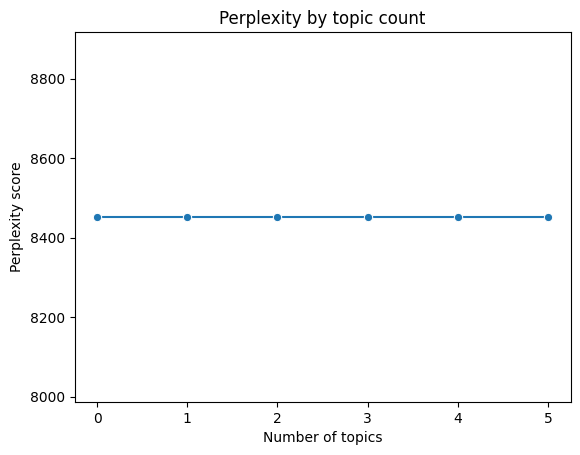

In [18]:
# Plot perplexity by topic count
ax = sns.lineplot(x = topic_nums, y = perplexity_score, marker = 'o')
ax.set_title('Perplexity by topic count')
ax.set_ylabel('Perplexity score'); ax.set_xlabel('Number of topics')
plt.show()

In [19]:
# Get the index of the topic with the highest probability for each document
dominant_topic_bones = np.argmax(bones_topics, axis=1)

# Create a DataFrame to view results clearly
df_dominant_topic_bones = pd.DataFrame({
    'Article_ID': range(len(dominant_topic_bones)),
    'Dominant_Topic': dominant_topic_bones,
    'Topic_Probability': np.max(bones_topics, axis=1)
})

df_dominant_topic_bones.head(1)

,Article_ID,Dominant_Topic,Topic_Probability
0,0,1,0.521411


In [20]:
# Patch the dominant topics in with the corresponding rows
bones_joined_df = pd.concat([bones_df,df_dominant_topic_bones], axis = 1)
bones_joined_df.head(1)

,Date,Source,Title,Description,page_url,Content,Article_ID,Dominant_Topic,Topic_Probability
0,2026-05-06,Gizmodo.com,Alaska’s Famous Fjords Are Becoming a Cruise S...,Climate change is making landslides and tsunam...,https://gizmodo.com/alaskas-famous-fjords-are-...,climate change is making landslides and tsunam...,0,1,0.521411


So, again - it is being a wee bit confused by the new data, but we can fix that with some better/more training data. The model is a work in progress.

# VADER

Let's apply some sentiment analysis to the news data

In [21]:
analyzer = SentimentIntensityAnalyzer()

# Apply sentiment analysis to each row
bones_joined_df['VADER_sentiment'] = bones_joined_df['Content'].apply(lambda x: analyzer.polarity_scores(x))

bones_joined_df.head(1)

,Date,Source,Title,Description,page_url,Content,Article_ID,Dominant_Topic,Topic_Probability,VADER_sentiment
0,2026-05-06,Gizmodo.com,Alaska’s Famous Fjords Are Becoming a Cruise S...,Climate change is making landslides and tsunam...,https://gizmodo.com/alaskas-famous-fjords-are-...,climate change is making landslides and tsunam...,0,1,0.521411,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound..."


In [22]:
# Expand VADER's output list into separate columns in its own mini frame
sentiment_expanded_df = pd.DataFrame(bones_joined_df['VADER_sentiment'].tolist(), index=bones_joined_df.index)
# rename the cols so they can be eyeballed easy later
sentiment_expanded_df.rename(columns={"neg":'vader_neg',"neu":"vader_neu","pos":'vader_pos',"compound":'vader_compound'}, inplace=True)
# Join the miniframe onto the big boi frame
bones_joined_df = pd.concat([bones_joined_df,sentiment_expanded_df],axis=1)

# Check that all worked
bones_joined_df.head(1)

,Date,Source,Title,Description,page_url,Content,Article_ID,Dominant_Topic,Topic_Probability,VADER_sentiment,vader_neg,vader_neu,vader_pos,vader_compound
0,2026-05-06,Gizmodo.com,Alaska’s Famous Fjords Are Becoming a Cruise S...,Climate change is making landslides and tsunam...,https://gizmodo.com/alaskas-famous-fjords-are-...,climate change is making landslides and tsunam...,0,1,0.521411,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0,1.0,0.0,0.0


And then to check that's all working let's just do some visualisation of one topic over time

In [23]:
# Put it into something I can work into a timeseries
bones_topic1_df = bones_joined_df.loc[bones_joined_df['Dominant_Topic'] == 1]

# Group by 'Date' and then get the compound score (I guess?)
bones_topic1_dfvader = bones_topic1_df.groupby('Date').agg(Compound_score = ('vader_compound', 'mean'))
bones_topic1_dfvader.reset_index(inplace=True)
bones_topic1_dfvader.head(5)

,Date,Compound_score
0,2026-04-12,0.802000
1,2026-04-13,0.349125
2,2026-04-14,0.542300
3,2026-04-15,0.891750
4,2026-04-16,0.286700


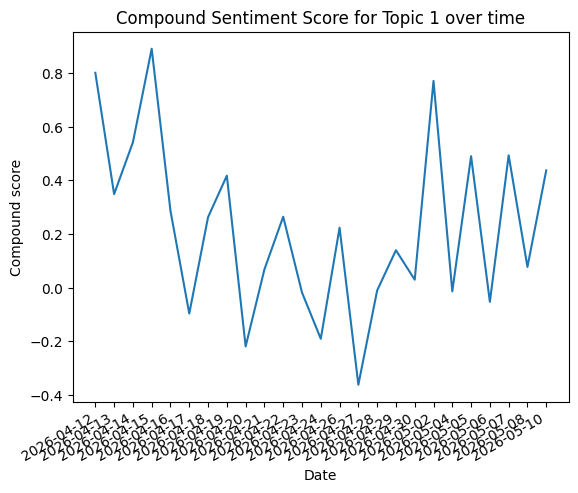

In [24]:
# Plotting the time series for Topic 4
plt.plot(bones_topic1_dfvader['Date'], bones_topic1_dfvader['Compound_score'])

# rotating the x-axis tick labels for readability
plt.xticks(rotation=30, ha='right')

# Add title
plt.title('Compound Sentiment Score for Topic 1 over time')

# Add appropriate x and y labels
plt.xlabel('Date')
plt.ylabel('Compound score')

plt.show()